# 07c. 디스크 단위 임계값 튜닝 및 운영점 선정 (Labeling Horizons: 10, 20, 30 Days)

이 노트북은 **07b** 노트북의 로직을 기반으로 하되, 고장 디스크에 대하여 리드타임(Lead Time) 조건(10일, 20일, 30일 이내)을 만족하는 알람만 True Positive(정탐)로 인정하도록 레이블링(Labeling)을 동적으로 변경해 가며 그리드 서치를 수행하고 성능을 평가합니다.


## 1. 환경 설정 및 라이브러리 로드

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))  # 프로젝트 루트 경로 추가

# 코드 변경 자동 반영 (autoreload)
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path

import config.threshold_config as cfg
from src.eval_core import (
    load_saved_ensemble,
    prepare_disk_level_data,
    run_disk_level_grid_search,
    evaluate_detailed_disk_point,
    plot_disk_far_recall_curves,
    plot_detailed_disk_analysis
)

# 한글 폰트 설정
import matplotlib.font_manager as fm
def set_korean_font():
    for name in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
print("✅ 환경 설정 및 라이브러리 로드 완료")


✅ 환경 설정 및 라이브러리 로드 완료


## 2. 최종 모델 및 val_calib 데이터 로드

In [2]:
print("🔄 최종 모델 로드 중...")
artifacts = load_saved_ensemble(cfg, require_threshold=False)
feature_cols = artifacts["feature_cols"]
ensemble = artifacts["ensemble"]
print(f"✅ 모델 로드 완료: {len(feature_cols)}개 피처")

print("🔄 val_calib 데이터 로드 중...")
val_calib_path = Path(cfg.VAL_CALIB_PATH)
df_val = pd.read_parquet(val_calib_path)
print(f"✅ 데이터 로드 완료: {len(df_val):,} 행")


🔄 최종 모델 로드 중...

[Data Path Contract]
  [OK] model save directory: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  [OK] feature columns: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (591 bytes)
[Model Artifact Contract]
  model_dir: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  feature_cols: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (27 features)
  model: subset_00.pkl (9,539,044 bytes)
  model: subset_01.pkl (9,555,780 bytes)
  model: subset_02.pkl (9,557,204 bytes)
  model: subset_03.pkl (9,556,372 bytes)
  model: subset_04.pkl (9,563,556 bytes)
  model: subset_05.pkl (9,557,892 bytes)
  model: subset_06.pkl (9,558,804 bytes)
  model: subset_07.pkl (9,548,164 bytes)
  model: subset_08.pkl (9,552,068 bytes)
  model: subset_09.pkl (9,530,612 bytes)
  joblib 로드 1/10: subset_00.pkl
      → 0.0s
  joblib 로드 2/10: subset_01.pkl
      → 0.0s
  joblib 로드 3/10

## 3. 앙상블 예측 수행 및 캐싱 (Validation Probabilities)

In [3]:
cache_path = os.path.join(cfg.MODEL_SAVE_DIR, "val_calib_probs.npy")

if os.path.exists(cache_path):
    print("♻️ 캐시된 예측 확률 파일 로드 중...")
    y_prob = np.load(cache_path)
    print(f"✅ 로드 완료: {len(y_prob):,}행")
else:
    t0 = time.perf_counter()
    print("🔄 앙상블 예측 수행 중...")
    y_prob = ensemble.predict_proba(df_val, feature_cols, verbose=True)
    np.save(cache_path, y_prob)
    print(f"✅ 예측 완료 및 캐시 저장 완료! 소요 시간: {time.perf_counter() - t0:.1f}초")

df_val['y_prob'] = y_prob


♻️ 캐시된 예측 확률 파일 로드 중...
✅ 로드 완료: 7,832,520행


## 4. 디스크 단위(Base Serial) 시계열 데이터 구성

In [4]:
print("🔄 시리얼별 정렬 및 그룹화 데이터 작성 중...")
t0 = time.perf_counter()
disks_data, n_failed_disks, n_normal_disks = prepare_disk_level_data(
    df_val, y_prob, target_col=cfg.TARGET_COL, serial_col=cfg.SERIAL_COL, date_col=cfg.DATE_COL
)
print(f"✅ 정렬 및 데이터 변환 완료: 총 {len(disks_data):,}개 디스크 (소요: {time.perf_counter() - t0:.2f}초)")
print(f"  - 고장 디스크 수 (Failed Disks) : {n_failed_disks:,}")
print(f"  - 정상 디스크 수 (Normal Disks) : {n_normal_disks:,}")


🔄 시리얼별 정렬 및 그룹화 데이터 작성 중...
✅ 정렬 및 데이터 변환 완료: 총 3,691개 디스크 (소요: 2.19초)
  - 고장 디스크 수 (Failed Disks) : 565
  - 정상 디스크 수 (Normal Disks) : 3,126


## 5. Horizon별(10일, 20일, 30일) 레이블링 변환 및 그리드 서치 수행
- `disks_data`에서 고장 디스크(`is_failed=1`)의 예측 확률(`probs`) 배열 중, **고장 발생일로부터 Horizon 이내**인 기간의 데이터만 유지하고 그 이전의 확률은 0.0으로 마스킹합니다.
- 이를 통해 지정된 리드타임 이내에 발생한 알람만 True Positive(정탐)로 집계되도록 합니다.
- 정상 디스크(`is_failed=0`)는 마스킹 없이 그대로 평가하여 모든 오탐(False Positive)을 엄격하게 집계합니다.


🚀 리드타임 10일 이내 탐지 기준 (Horizon: 10 Days)
  ... 500/1,000 (50.0%) - 0.0s
  ... 1,000/1,000 (100.0%) - 0.0s
✅ 벡터화 그리드 서치 완료: 총 1000개 조합 탐색 완료 (소요: 0.0680초)

[ 오탐율(Disk FAR) 상한별 최적 운영점 도출 ]
 FPR Cap   | min_alarms | threshold  | Disk Recall  |  Disk FAR  | Lead Time  | Precision  |  Persist. 
-------------------------------------------------------------------------------------------------------------------
  0.10   % |     1      |   0.9820   |    13.98   % |   0.10   % |    3.5     |   96.34  % |   70.18  %
  0.50   % |     1      |   0.9720   |    21.77   % |   0.48   % |    4.5     |   89.13  % |   69.01  %
  1.00   % |     1      |   0.9590   |    28.32   % |   0.99   % |    4.7     |   83.77  % |   77.83  %
  2.00   % |     1      |   0.9401   |    35.04   % |   1.95   % |    5.2     |   76.45  % |   79.90  %
  3.00   % |     1      |   0.9211   |    40.18   % |   2.98   % |    5.6     |   70.94  % |   80.68  %
  5.00   % |     1      |   0.8511   |    50.80   % |   4.99   % |    6.0 

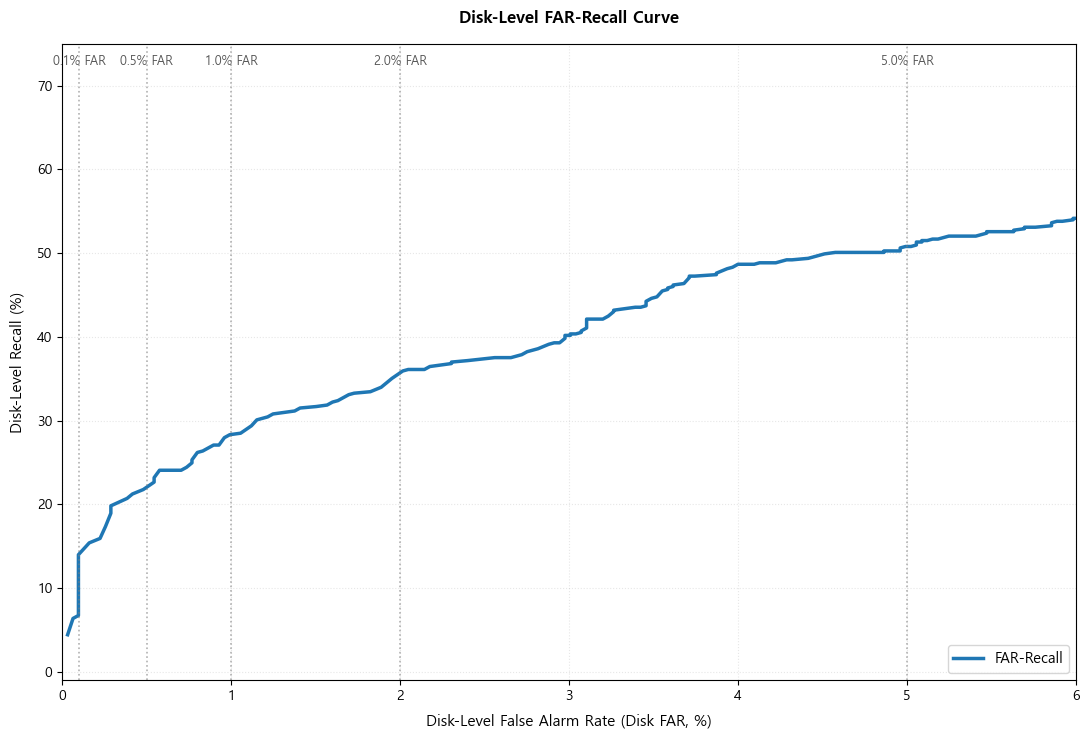


🚀 리드타임 20일 이내 탐지 기준 (Horizon: 20 Days)
  ... 500/1,000 (50.0%) - 0.0s
  ... 1,000/1,000 (100.0%) - 0.0s
✅ 벡터화 그리드 서치 완료: 총 1000개 조합 탐색 완료 (소요: 0.0602초)

[ 오탐율(Disk FAR) 상한별 최적 운영점 도출 ]
 FPR Cap   | min_alarms | threshold  | Disk Recall  |  Disk FAR  | Lead Time  | Precision  |  Persist. 
-------------------------------------------------------------------------------------------------------------------
  0.10   % |     1      |   0.9820   |    14.51   % |   0.10   % |    5.4     |   96.47  % |   66.52  %
  0.50   % |     1      |   0.9720   |    22.65   % |   0.48   % |    6.6     |   89.51  % |   65.88  %
  1.00   % |     1      |   0.9590   |    29.91   % |   0.99   % |    7.6     |   84.50  % |   72.48  %
  2.00   % |     1      |   0.9401   |    37.17   % |   1.95   % |    8.9     |   77.49  % |   72.82  %
  3.00   % |     1      |   0.9211   |    41.95   % |   2.98   % |    9.3     |   71.82  % |   76.67  %
  5.00   % |     1      |   0.8511   |    52.39   % |   4.99   % |    10.2

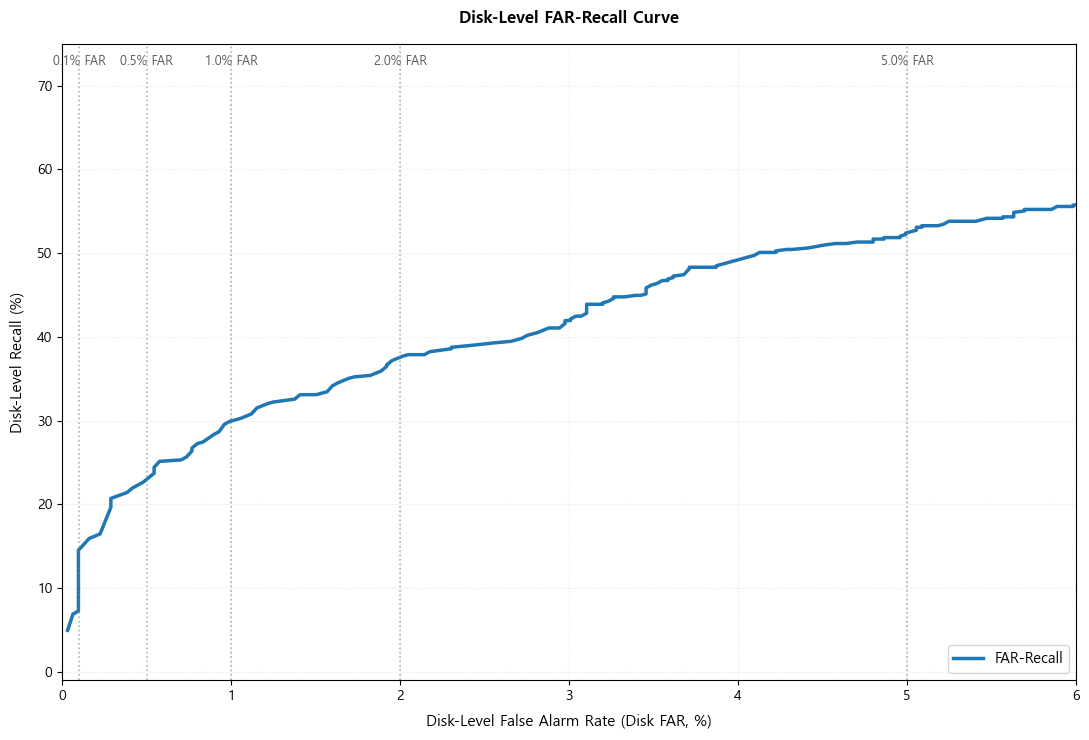


🚀 리드타임 30일 이내 탐지 기준 (Horizon: 30 Days)
  ... 500/1,000 (50.0%) - 0.0s
  ... 1,000/1,000 (100.0%) - 0.0s
✅ 벡터화 그리드 서치 완료: 총 1000개 조합 탐색 완료 (소요: 0.0630초)

[ 오탐율(Disk FAR) 상한별 최적 운영점 도출 ]
 FPR Cap   | min_alarms | threshold  | Disk Recall  |  Disk FAR  | Lead Time  | Precision  |  Persist. 
-------------------------------------------------------------------------------------------------------------------
  0.10   % |     1      |   0.9820   |    15.04   % |   0.10   % |    7.1     |   96.59  % |   63.14  %
  0.50   % |     1      |   0.9720   |    24.07   % |   0.48   % |    9.2     |   90.07  % |   60.77  %
  1.00   % |     1      |   0.9590   |    30.80   % |   0.99   % |    10.1    |   84.88  % |   68.75  %
  2.00   % |     1      |   0.9401   |    38.05   % |   1.95   % |    11.5    |   77.90  % |   69.87  %
  3.00   % |     1      |   0.9211   |    43.01   % |   2.98   % |    12.0    |   72.32  % |   73.76  %
  5.00   % |     1      |   0.8511   |    54.87   % |   4.99   % |    14.0

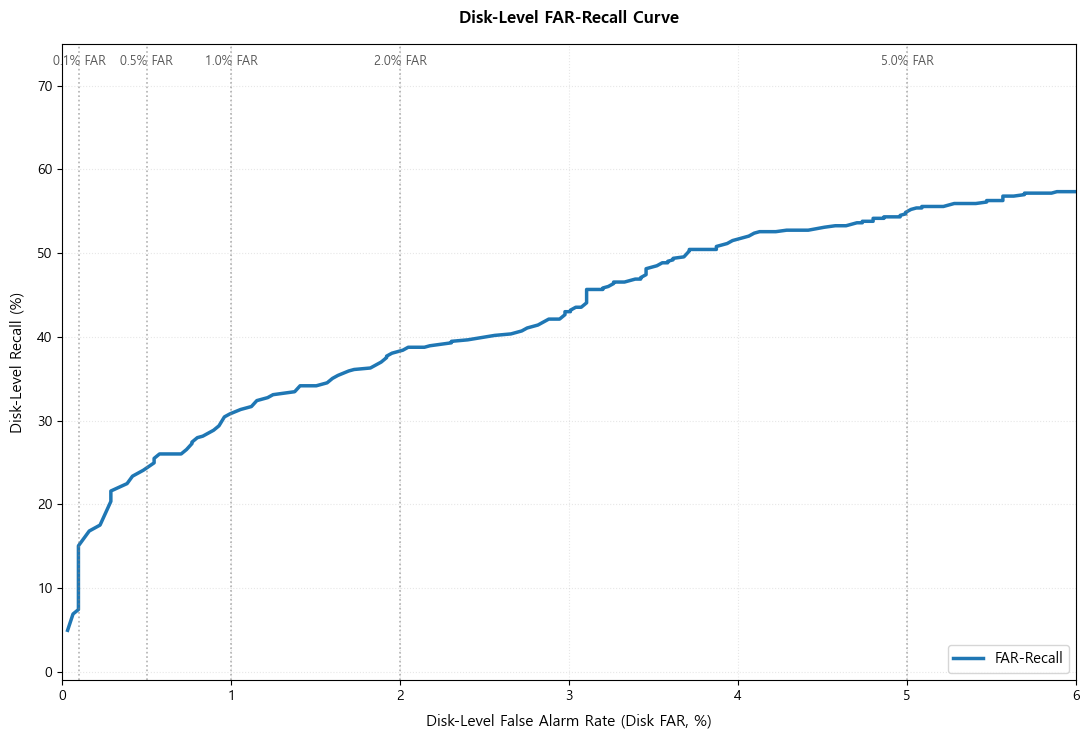

In [5]:
import pandas as pd
import copy
from IPython.display import display

horizons = [10, 20, 30, 40, 50]
thresholds = np.linspace(0.001, 0.999, 1000)
min_alarms_list = [1]
target_far_caps = [0.001, 0.005, 0.010, 0.020, 0.030, 0.050]

for horizon in horizons:
    print('\n' + '='*80)
    print(f'🚀 리드타임 {horizon}일 이내 탐지 기준 (Horizon: {horizon} Days)')
    print('='*80)


    # 2. 그리드 서치 수행
    t_grid = time.perf_counter()
    df_grid = run_disk_level_grid_search(disks_data, thresholds, min_alarms_list, n_failed_disks, n_normal_disks, log_dir=cfg.MODEL_SAVE_DIR, window_size=0, horizon=horizon)
    grid_csv_path = os.path.join(cfg.MODEL_SAVE_DIR, f'disk_level_grid_search_results_{horizon}d.csv')
    df_grid.to_csv(grid_csv_path, index=False, encoding='utf-8-sig')
    print(f'✅ 벡터화 그리드 서치 완료: 총 {len(df_grid)}개 조합 탐색 완료 (소요: {time.perf_counter() - t_grid:.4f}초)')

    # 3. FAR Cap별 최적 운영점 출력
    print('\n[ 오탐율(Disk FAR) 상한별 최적 운영점 도출 ]')
    print('=' * 115)
    print(f"{'FPR Cap':^10} | {'min_alarms':^10} | {'threshold':^10} | {'Disk Recall':^12} | {'Disk FAR':^10} | {'Lead Time':^10} | {'Precision':^10} | {'Persist.':^10}")
    print('-' * 115)
    
    best_row_for_plot = None
    for cap in target_far_caps:
        sub = df_grid[df_grid['far'] <= cap]
        if len(sub) == 0:
            print(f"{cap*100:^9.2f}% | {'-':^10} | {'-':^10} | {'-':^12} | {'-':^10} | {'-':^10} | {'-':^10} | {'-':^10}")
            continue
        best_row = sub.sort_values('recall', ascending=False).iloc[0]
        if cap == 0.01:
            best_row_for_plot = best_row
            
        det = evaluate_detailed_disk_point(
            disks_data, best_row['threshold'], int(best_row['min_alarms']),
            n_failed_disks, n_normal_disks, far_cap=cap, window_size=0, horizon=horizon
        )
        print(f"{cap*100:^9.2f}% | {int(best_row['min_alarms']):^10d} | {best_row['threshold']:^10.4f} | "
              f"{best_row['recall']*100:^11.2f}% | {best_row['far']*100:^9.2f}% | "
              f"{det.get('lead_time', 0):^10.1f} | {det.get('precision', 0)*100:^9.2f}% | {det.get('persistence', 0)*100:^9.2f}%")
    print('=' * 115 + '\n')

    # 4. 그래프 출력
    if best_row_for_plot is not None:
        print(f'🎯 [Horizon {horizon} Days] 적용할 최적 운영점 (FAR 1.0% 상한): 임계값 T = {best_row_for_plot["threshold"]:.4f} (단일 알람 기준)')
        plot_disk_far_recall_curves(df_grid, min_alarms_list, best_row_for_plot)
    else:
        print(f'[Horizon {horizon} Days] FAR 1.0% 이하를 만족하는 운영점이 없습니다.')

